# State-Aware Yaw Update

This notebook revisits the final T3 submission after external leaderboard evidence showed that the previous **constant-per-turbine** deployment did not transfer well:

- validation: MAE ≈ **5.25°**
- final: MAE ≈ **3.39°**

The earlier physics model remains useful as a **long-term absolute level estimator**, but the teammate T3 output shows a clear piecewise-constant temporal state structure.

For PPP_WTG17:

\[
\hat y_{\mathrm{teammate}}(t)=\mu_{\mathrm{teammate}}+\delta(t)
\]

We construct one low-degree-of-freedom hybrid:

\[
\hat y_{\mathrm{hybrid}}(t)
=
L_{\mathrm{physics}}
+
\left[
\hat y_{\mathrm{teammate}}(t)-\mu_{\mathrm{teammate}}
\right].
\]

This preserves the teammate model's **temporal state changes and cluster labels**, while anchoring the long-term mean to the frozen physics estimate.

This is an exploratory competition update. It is **not** claimed as newly validated on hidden labels.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()

def find_file(name):
    candidates = [
        ROOT / name,
        ROOT.parent / name,
        Path("/mnt/data") / name,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(name)

TEAMMATE_VALIDATE = find_file("DR_Results_33_T3_0.csv")
TEMPLATE_VALIDATE = find_file("submission_template_validate.csv")

FROZEN_PPP17_LEVEL = -3.596
FROZEN_SSS06_LEVEL = -4.568

mate = pd.read_csv(TEAMMATE_VALIDATE)
template = pd.read_csv(TEMPLATE_VALIDATE)

print("teammate rows:", len(mate))
print("template rows:", len(template))
display(mate.head())


teammate rows: 731
template rows: 731


,turbine_id,date,yaw_misalignment_deg,cluster
0,PPP_WTG17,2024-10-17,0.258,1
1,PPP_WTG17,2024-11-21,0.258,1
2,PPP_WTG17,2023-01-15,-7.235,0
3,PPP_WTG17,2024-12-25,0.258,1
4,PPP_WTG17,2023-03-07,-7.235,0


## 1. Lock to the official validation template

The submission is aligned by exact `(turbine_id, date)` keys. No date ordering is assumed.


In [2]:
keys = ["turbine_id", "date"]

aligned = template[keys].merge(
    mate[keys + ["yaw_misalignment_deg", "cluster"]],
    on=keys,
    how="left",
    validate="one_to_one",
)

assert len(aligned) == 731
assert aligned["yaw_misalignment_deg"].notna().all()
assert aligned["cluster"].notna().all()

print("Exact template coverage: OK")


Exact template coverage: OK


## 2. Inspect the teammate temporal structure

The teammate prediction is not daily jitter. It is a small number of persistent yaw regimes.


In [3]:
ts = mate.copy()
ts["date"] = pd.to_datetime(ts["date"])
ts = ts.sort_values("date")

summary = (
    ts.groupby("cluster")
      .agg(
          start=("date", "min"),
          end=("date", "max"),
          days=("date", "size"),
          yaw=("yaw_misalignment_deg", "first"),
      )
)

display(summary)

changes = ts.loc[
    ts["cluster"].ne(ts["cluster"].shift()),
    ["date", "cluster", "yaw_misalignment_deg"]
]
print("State changes:")
display(changes)

print("Temporal mean:", ts["yaw_misalignment_deg"].mean())
print("Temporal std :", ts["yaw_misalignment_deg"].std())


,start,end,days,yaw
cluster,,,,
0,2023-01-01,2024-01-05,370,-7.235
1,2024-01-06,2024-12-31,361,0.258


State changes:


,date,cluster,yaw_misalignment_deg
434,2023-01-01,0,-7.235
696,2024-01-06,1,0.258


Temporal mean: -3.5346265389876885
Temporal std : 3.748781059799094


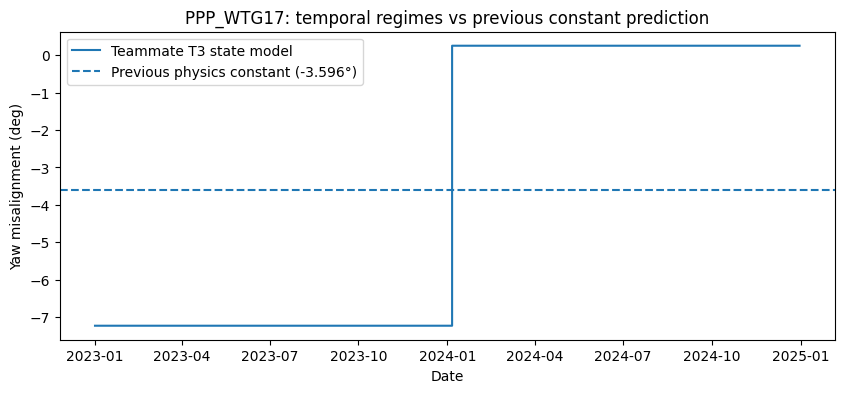

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.step(
    ts["date"],
    ts["yaw_misalignment_deg"],
    where="post",
    label="Teammate T3 state model",
)
ax.axhline(
    FROZEN_PPP17_LEVEL,
    linestyle="--",
    label=f"Previous physics constant ({FROZEN_PPP17_LEVEL:.3f}°)",
)
ax.set_ylabel("Yaw misalignment (deg)")
ax.set_xlabel("Date")
ax.set_title("PPP_WTG17: temporal regimes vs previous constant prediction")
ax.legend()
plt.show()


## 3. State-aware physics recentering

Keep the teammate temporal residual exactly:

\[
\delta(t)=\hat y_{\mathrm{teammate}}(t)-\overline{\hat y}_{\mathrm{teammate}}
\]

and replace only its long-term center:

\[
\hat y_{\mathrm{hybrid}}(t)=L_{\mathrm{physics}}+\delta(t).
\]

This adds **no new temporal hyperparameter** and leaves the cluster boundaries unchanged.


In [5]:
teammate_mean = aligned["yaw_misalignment_deg"].mean()
shift = FROZEN_PPP17_LEVEL - teammate_mean

aligned["dynamic_residual"] = (
    aligned["yaw_misalignment_deg"] - teammate_mean
)
aligned["hybrid_yaw"] = (
    FROZEN_PPP17_LEVEL + aligned["dynamic_residual"]
)

state_compare = (
    pd.DataFrame({
        "cluster": aligned["cluster"],
        "teammate": aligned["yaw_misalignment_deg"],
        "hybrid": aligned["hybrid_yaw"],
    })
    .groupby("cluster")
    .first()
)

print(f"Teammate temporal mean : {teammate_mean:.6f}°")
print(f"Physics long-term level: {FROZEN_PPP17_LEVEL:.6f}°")
print(f"Required recenter shift: {shift:+.6f}°")
display(state_compare.round(6))


Teammate temporal mean : -3.534627°
Physics long-term level: -3.596000°
Required recenter shift: -0.061373°


,teammate,hybrid
cluster,,
0,-7.235,-7.296373
1,0.258,0.196627


The shift is intentionally diagnostic: if the two independent methods already agree on the long-term center, the hybrid should differ mainly by adding the missing state dynamics rather than inventing a new absolute calibration.


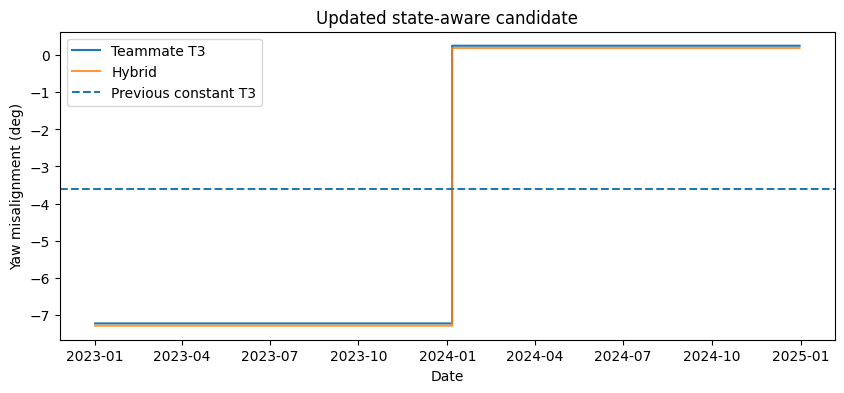

In [6]:
hybrid_ts = template[["turbine_id", "date"]].copy()
hybrid_ts["date"] = pd.to_datetime(hybrid_ts["date"])
hybrid_ts["yaw"] = aligned["hybrid_yaw"].to_numpy()
hybrid_ts["cluster"] = aligned["cluster"].to_numpy()
hybrid_ts = hybrid_ts.sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(ts["date"], ts["yaw_misalignment_deg"], where="post", label="Teammate T3")
ax.step(hybrid_ts["date"], hybrid_ts["yaw"], where="post", label="Hybrid", alpha=0.8)
ax.axhline(FROZEN_PPP17_LEVEL, linestyle="--", label="Previous constant T3")
ax.set_ylabel("Yaw misalignment (deg)")
ax.set_xlabel("Date")
ax.set_title("Updated state-aware candidate")
ax.legend()
plt.show()


## 4. Generate the next validation submission

The existing `T3 / Sub #0` is already scored, so this candidate uses **Sub #1**:

`Results_33_T3_1.csv`

The official final-round file is not rewritten here. The previously merged `_final` submission is immutable under the challenge rules, and a state-aware final candidate requires the teammate's **SSS_WTG06 temporal output** rather than transferring PPP_WTG17 state dates to another turbine/site.


In [7]:
out = template.copy()
out["yaw_misalignment_deg"] = aligned["hybrid_yaw"].to_numpy()
out["cluster"] = aligned["cluster"].astype(int).to_numpy()

OUTPUT = ROOT / "Results_33_T3_1.csv"

# Safety checks equivalent to the organizer format requirements.
assert list(out.columns[:3]) == [
    "turbine_id", "date", "yaw_misalignment_deg"
]
assert len(out) == 731
assert not out[["turbine_id", "date"]].duplicated().any()
assert pd.to_numeric(out["yaw_misalignment_deg"], errors="coerce").notna().all()
assert out["yaw_misalignment_deg"].abs().max() <= 90
assert out["cluster"].notna().all()

out.to_csv(OUTPUT, index=False, float_format="%.6f")
print("Wrote:", OUTPUT)
print("Rows:", len(out))
print("Clusters:", out["cluster"].nunique())
display(out.head())


Wrote: /mnt/data/Results_33_T3_1.csv
Rows: 731
Clusters: 2


,turbine_id,date,yaw_misalignment_deg,cluster
0,PPP_WTG17,2024-10-17,0.196627,1
1,PPP_WTG17,2024-11-21,0.196627,1
2,PPP_WTG17,2023-01-15,-7.296373,0
3,PPP_WTG17,2024-12-25,0.196627,1
4,PPP_WTG17,2023-03-07,-7.296373,0


## 5. What is still needed for a final-round state-aware candidate

Do **not** transfer the PPP_WTG17 change date (`2024-01-06`) to SSS_WTG06.

To create a defensible SSS final candidate, provide the teammate T3/T0 final prediction for SSS_WTG06. Then apply the same decomposition:

\[
\text{SSS temporal shape} \rightarrow
\delta_{\mathrm{SSS}}(t)
\]

and separately decide whether its long-term center should remain the teammate level or be recentered to the physics level `-4.568°`.

Because the existing `_final` file has already been merged/scored, any revised final entry also requires organizer approval under the immutable-submission rule.
